# **Análisis y Limpieza de Datos Avocado.csv**


| Columna      | Descripción                                                                                          |
| ------------ | ---------------------------------------------------------------------------------------------------- |
| Unnamed: 0   | Índice generado automáticamente al exportar el dataset. No contiene información analítica relevante. |
| Date         | Fecha de observación del registro. Representa el periodo de venta.                                   |
| AveragePrice | Precio promedio de los aguacates en dólares para la región y fecha específica.                       |
| Total Volume | Volumen total de aguacates vendidos. Incluye ventas individuales y en bolsas.                        |
| 4046         | Número de aguacates vendidos del tipo PLU 4046 (generalmente tamaño pequeño).                        |
| 4225         | Número de aguacates vendidos del tipo PLU 4225 (generalmente tamaño mediano).                        |
| 4770         | Número de aguacates vendidos del tipo PLU 4770 (generalmente tamaño grande).                         |
| Total Bags   | Total de aguacates vendidos en bolsas. Es la suma de Small, Large y XLarge Bags.                     |
| Small Bags   | Número de aguacates vendidos en bolsas pequeñas.                                                     |
| Large Bags   | Número de aguacates vendidos en bolsas grandes.                                                      |
| XLarge Bags  | Número de aguacates vendidos en bolsas extra grandes.                                                |
| type         | Tipo de aguacate: conventional o organic.                                                            |
| year         | Año correspondiente al registro.                                                                     |
| region       | Región geográfica de las ventas. Puede representar ciudades, estados o regiones agregadas.           |


## 1. **Importación de Librerias**

In [272]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [273]:
df = pd.read_csv('avocado.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [274]:
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


## 2. **Exploración del Dataset**

In [275]:
df = pd.read_csv('avocado.csv')

print(f"Dimensiones del dataset: {df.shape}")
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"\nValores nulos por columna:")
print(df.isnull().sum())
print()
df.info()

Dimensiones del dataset: (18249, 14)
Filas duplicadas: 0

Valores nulos por columna:
Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249

Se observa la existencia de una columna llamada "Unnamed: 0", la cual no aporta valor al análisis, ya que únicamente representa un índice generado automáticamente durante la exportación del dataset. Por lo tanto, esta columna se considera redundante y puede ser eliminada sin afectar la integridad de los datos.

In [276]:
# Eliminación de la columna 'Unnamed: 0'
df = df.drop(columns=['Unnamed: 0'])

In [277]:
df.describe()

,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


## 2. **Visualización de Valores Nulos**

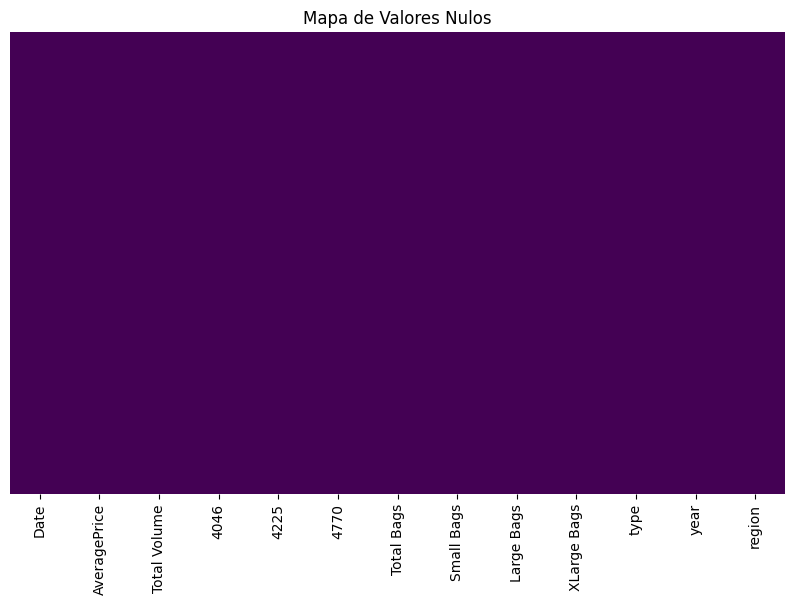

In [278]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de Valores Nulos')
plt.show()

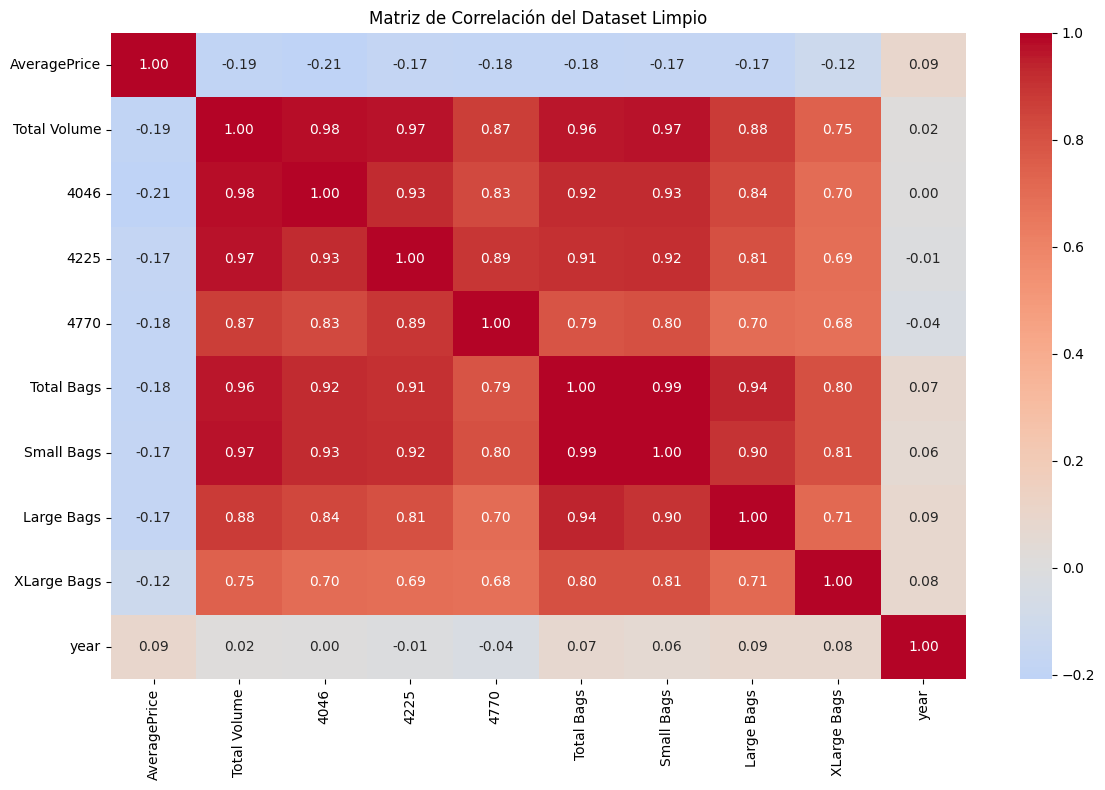

In [279]:
# Mapa de correlación del dataset limpio
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación del Dataset Limpio')
plt.tight_layout()
plt.show()

### *--> No se observan Valores Nulos*

## **4. Manejo de Duplicados**

In [280]:
# Detectar duplicados

print(f"Filas duplicadas encontradas: {df.duplicated().sum()}")


Filas duplicadas encontradas: 0


### *--> No hay valores Duplicados*

In [281]:
df.type.value_counts()

type
conventional    9126
organic         9123
Name: count, dtype: int64

In [282]:
df.Date.value_counts()

Date
2015-12-27    108
2015-12-20    108
2015-12-13    108
2015-11-29    108
2015-11-22    108
             ... 
2018-02-04    108
2018-01-07    108
2015-12-06    107
2017-06-25    107
2017-06-18    107
Name: count, Length: 169, dtype: int64

## **5. Detección de Valores Atípicos**

### *5.1 Transformando Valores*

Según la descripción del dataset, las variables *Total Volume*, *4046*, *4225* y *4770*, representan el número total de aguacates vendidos.

Sin embargo, al observar los datos, se identifican valores decimales, lo cual sugiere que no se trata de conteos discretos exactos, sino de valores agregados, promedios o estimaciones del volumen de ventas.

Por esta razón, no se recomienda transformar estas variables a enteros, ya que los decimales contienen información relevante y su eliminación podría introducir errores en el análisis.


### *5.2 Comprobemos que las variables corresponden a su descripción*.

Analizando la estructura del Dataset y su composición se quiere llegar a comprender de donde provienen lo valores Total Volume y Total Bags realmente y si estos tienen consistencia en base a lo que se pueda intuir de ellos

#### **1° Comportamiento de *Total Volume***

Según la descripción del dataset, *Total Volume* corresponde a la cantidad total de aguacates vendidos. Esto se puede expresar como la suma de las diferentes categorías:

*df[Total Volume] = df[4046] + df[4225] + df[4770]*

Para comprobarlo, podemos calcular la suma de estas columnas y compararla con el valor registrado en *Total Volume* para cada fila del dataset.

In [283]:
for i in range (len(df)): 
    total_calculated = df.loc[i, '4046'] + df.loc[i, '4225'] + df.loc[i, '4770']
    total_calculated = total_calculated.round(2)
    if total_calculated != df.loc[i, 'Total Volume']: 
        print(f"Discrepancia en fila {i}: Total Volume = {df.loc[i, 'Total Volume']}, Calculado = {total_calculated}")

Discrepancia en fila 0: Total Volume = 64236.62, Calculado = 55539.75
Discrepancia en fila 1: Total Volume = 54876.98, Calculado = 45371.42
Discrepancia en fila 2: Total Volume = 118220.22, Calculado = 110074.87
Discrepancia en fila 3: Total Volume = 78992.15, Calculado = 73180.99
Discrepancia en fila 4: Total Volume = 51039.6, Calculado = 44855.65
Discrepancia en fila 5: Total Volume = 55979.78, Calculado = 49295.87
Discrepancia en fila 6: Total Volume = 83453.76, Calculado = 75134.9
Discrepancia en fila 7: Total Volume = 109428.33, Calculado = 102599.11
Discrepancia en fila 8: Total Volume = 99811.42, Calculado = 88423.06
Discrepancia en fila 9: Total Volume = 74338.76, Calculado = 65712.84
Discrepancia en fila 10: Total Volume = 84843.44, Calculado = 76637.78
Discrepancia en fila 11: Total Volume = 64489.17, Calculado = 54365.27
Discrepancia en fila 12: Total Volume = 61007.1, Calculado = 52250.35
Discrepancia en fila 13: Total Volume = 106803.39, Calculado = 100768.93
Discrepancia 

In [284]:
df['Total Volume'].head(10)

0     64236.62
1     54876.98
2    118220.22
3     78992.15
4     51039.60
5     55979.78
6     83453.76
7    109428.33
8     99811.42
9     74338.76
Name: Total Volume, dtype: float64

Como podemos observar, encontramos discrepancias desde la fila 0 entre los totales del dataset y los calculados manualmente. Pero, ¿por qué sucede esto? 

La razón es que existen variables adicionales que influyen en el cálculo de *Total Volume* y que inicialmente no fueron consideradas.

Para comprobarlo, tomemos en cuenta las columnas: *Total Bags*, *Small Bags*, *Large Bags* y *XLarge Bags*.

### **¿Por qué son importantes estas variables? ¿Qué representan?**

Al analizarlas, podemos concluir que estas variables hacen referencia a la cantidad de aguacates vendidos en diferentes tipos de empaque (bolsas):

- *Small Bags*: volumen vendido en bolsas pequeñas  
- *Large Bags*: volumen vendido en bolsas grandes  
- *XLarge Bags*: volumen vendido en bolsas extra grandes  

#### **2° Comportamiento de *Total Bags***
*Total Bags* corresponde a la cantidad total de aguacates vendidos en formato de bolsas. Esto se puede expresar intuitivamente como la suma de las diferentes categorías de bolsas.

*Total Bags = df[Small Bags] + [Large Bags] + [XLarge Bags]*

Para comprobarlo, podemos calcular la suma de estas columnas y compararla con el valor registrado en *Total Bags* para cada fila del dataset.

In [285]:
for i in range (len(df)): 
    total_calculated = df.loc[i, 'Small Bags'] + df.loc[i, 'Large Bags'] + df.loc[i, 'XLarge Bags']
    total_calculated = total_calculated.round(2)
    if total_calculated != df.loc[i, 'Total Bags']: 
        print(f"Discrepancia en fila {i}: Total Bags = {df.loc[i, 'Total Bags']}, Calculado = {total_calculated}")

Discrepancia en fila 5621: Total Bags = 11426.0, Calculado = 11427.0
Discrepancia en fila 5673: Total Bags = 207280.0, Calculado = 207279.0
Discrepancia en fila 5727: Total Bags = 189136.0, Calculado = 189135.0
Discrepancia en fila 5780: Total Bags = 19551.0, Calculado = 19550.0
Discrepancia en fila 5782: Total Bags = 37274.0, Calculado = 37273.0
Discrepancia en fila 5833: Total Bags = 106195.0, Calculado = 106194.0
Discrepancia en fila 5835: Total Bags = 84655.0, Calculado = 84654.0
Discrepancia en fila 5886: Total Bags = 45769.0, Calculado = 45770.0
Discrepancia en fila 6045: Total Bags = 74100.0, Calculado = 74099.0
Discrepancia en fila 6047: Total Bags = 82312.0, Calculado = 82313.0
Discrepancia en fila 6097: Total Bags = 163245.0, Calculado = 163246.0
Discrepancia en fila 6099: Total Bags = 152289.0, Calculado = 152290.0
Discrepancia en fila 6100: Total Bags = 198609.0, Calculado = 198608.0
Discrepancia en fila 6152: Total Bags = 75591.0, Calculado = 75592.0
Discrepancia en fila 6

In [286]:

suma = df['Small Bags'][5622] + df['Large Bags'][5622] + df['XLarge Bags'][5622] 
print(f"Suma de Small, Large, XLarge Bags en fila 5622: {suma}")
print(f"Valor en fila 5622 para Total Bags: {df['Total Bags'][5622]}")

suma2 = df['4046'][5622] + df['4225'][5622] + df['4770'][5622]
print(f"Suma de 4046, 4225, 4770 en fila 5622: {suma2}")

print(f"Valor en fila 5622 para Total Volume: {df['Total Volume'][5622]}")

print(f"Suma {suma2 + df['Total Bags'][5622]}")


Suma de Small, Large, XLarge Bags en fila 5622: 13940.0
Valor en fila 5622 para Total Bags: 13940.0
Suma de 4046, 4225, 4770 en fila 5622: 83334.0
Valor en fila 5622 para Total Volume: 97273.0
Suma 97274.0


Como podemos observar, encontramos discrepancias desde la fila 5621 en adelante entre los totales del dataset y los calculados manualmente.

Con el fin de corregir restas incosistencias sustituiremos los totales presentes en el dataset para *Total Bags* por los que calculamos manualmente

#### **3° Corrigiendo *Total Bags***

In [287]:
df['Total Bags'] = round(df['Small Bags'] + df['Large Bags'] + df['XLarge Bags'], 2)
df['Total Bags'].head(10)


df

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
18245,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
18246,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
18247,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico


In [288]:
suma = df['Small Bags'][5622] + df['Large Bags'][5622] + df['XLarge Bags'][5622] 
print(f"Suma de Small, Large, XLarge Bags en fila 5622: {suma}")
print(f"Valor en fila 5622 para Total Bags: {df['Total Bags'][5622]}")


suma2 = df['4046'][5622] + df['4225'][5622] + df['4770'][5622]
print(f"Suma de 4046, 4225, 4770 en fila 5622: {suma2}")


print(f"Valor en fila 5622 para Total Volume: {df['Total Volume'][5622]}")

print(f"Suma {suma2 + df['Total Bags'][5622]}")

Suma de Small, Large, XLarge Bags en fila 5622: 13940.0
Valor en fila 5622 para Total Bags: 13940.0
Suma de 4046, 4225, 4770 en fila 5622: 83334.0
Valor en fila 5622 para Total Volume: 97273.0
Suma 97274.0


In [289]:
for i in range (len(df)): 
    total_calculated = df.loc[i, 'Small Bags'] + df.loc[i, 'Large Bags'] + df.loc[i, 'XLarge Bags']
    total_calculated = total_calculated.round(2)
    if total_calculated != df.loc[i, 'Total Bags']: 
        print(f"Discrepancia en fila {i}: Total Bags = {df.loc[i, 'Total Bags']}, Calculado = {total_calculated}")
else:
    print("No se encontraron discrepancias en Total Bags después de la corrección.")

No se encontraron discrepancias en Total Bags después de la corrección.


#### **4° Corrigiendo *Total Volume***

In [290]:
for i in range (len(df)): 
    total_calculated = df.loc[i, '4046'] + df.loc[i, '4225'] + df.loc[i, '4770'] + df.loc[i, 'Total Bags']
    total_calculated = total_calculated.round(2)
    if total_calculated != df.loc[i, 'Total Volume']: 
        print(f"Discrepancia en fila {i}: Total Volume = {df.loc[i, 'Total Volume']}, Calculado = {total_calculated}")

Discrepancia en fila 5621: Total Volume = 62977.0, Calculado = 62978.0
Discrepancia en fila 5622: Total Volume = 97273.0, Calculado = 97274.0
Discrepancia en fila 5623: Total Volume = 113586.0, Calculado = 113585.0
Discrepancia en fila 5727: Total Volume = 629719.0, Calculado = 629718.0
Discrepancia en fila 5780: Total Volume = 54681.0, Calculado = 54680.0
Discrepancia en fila 5781: Total Volume = 60602.0, Calculado = 60603.0
Discrepancia en fila 5782: Total Volume = 81827.0, Calculado = 81826.0
Discrepancia en fila 5833: Total Volume = 423778.0, Calculado = 423777.0
Discrepancia en fila 5834: Total Volume = 476236.0, Calculado = 476237.0
Discrepancia en fila 5835: Total Volume = 639092.0, Calculado = 639090.0
Discrepancia en fila 5888: Total Volume = 118434.0, Calculado = 118433.0
Discrepancia en fila 5938: Total Volume = 5544556.0, Calculado = 5544557.0
Discrepancia en fila 5939: Total Volume = 4392810.0, Calculado = 4392809.0
Discrepancia en fila 5941: Total Volume = 5637795.0, Calc

In [291]:
df['Total Volume'] = round(df['4046'] + df['4225'] + df['4770'] + df['Total Bags'], 2)
df['Total Volume'].head(10)

0     64236.62
1     54876.98
2    118220.22
3     78992.15
4     51039.60
5     55979.78
6     83453.76
7    109428.33
8     99811.42
9     74338.76
Name: Total Volume, dtype: float64

In [292]:
for i in range (len(df)): 
    total_calculated = df.loc[i, '4046'] + df.loc[i, '4225'] + df.loc[i, '4770'] + df.loc[i, 'Total Bags']
    total_calculated = total_calculated.round(2)
    if total_calculated != df.loc[i, 'Total Volume']: 
        print(f"Discrepancia en fila {i}: Total Volume = {df.loc[i, 'Total Volume']}, Calculado = {total_calculated}")
else:
    print("No se encontraron discrepancias en Total Volume después de la corrección.")

No se encontraron discrepancias en Total Volume después de la corrección.


In [293]:
suma = df['Small Bags'][5622] + df['Large Bags'][5622] + df['XLarge Bags'][5622] 
print(f"Suma de Small, Large, XLarge Bags en fila 5622: {suma}")
print(f"Valor en fila 5622 para Total Bags: {df['Total Bags'][5622]}")


suma2 = df['4046'][5622] + df['4225'][5622] + df['4770'][5622]
print(f"Suma de 4046, 4225, 4770 en fila 5622: {suma2}")


print(f"Valor en fila 5622 para Total Volume: {df['Total Volume'][5622]}")

print(f"Suma {suma2 + df['Total Bags'][5622]}")

Suma de Small, Large, XLarge Bags en fila 5622: 13940.0
Valor en fila 5622 para Total Bags: 13940.0
Suma de 4046, 4225, 4770 en fila 5622: 83334.0
Valor en fila 5622 para Total Volume: 97274.0
Suma 97274.0


In [294]:
for i in range (len(df)): 
    total_calculated = df.loc[i, '4046'] + df.loc[i, '4225'] + df.loc[i, '4770'] + df.loc[i, 'Large Bags'] + df.loc[i, 'Small Bags'] + df.loc[i, 'XLarge Bags']
    total_calculated = total_calculated.round(2)
    if total_calculated != df.loc[i, 'Total Volume']: 
        print(f"Discrepancia en fila {i}: Total Volume = {df.loc[i, 'Total Volume']}, Calculado = {total_calculated}")
else:
    print("No se encontraron discrepancias en Total Volume después de la corrección.")

No se encontraron discrepancias en Total Volume después de la corrección.


## **6. Codificación de Variables Categoricas**

Usamos One-Hot Encoding para convertir 'Departamento' en variables binarias.

One-Hot Encoding convierte una columna categórica en **múltiples columnas binarias** (columnas dummy). Cada categoría se convierte en una columna con valores 0 o 1.

Usamos `drop='first'` para evitar la **trampa de la multicolinealidad** (si tenemos N categorías, solo necesitamos N-1 columnas).

In [295]:
df['type'].value_counts()

type
conventional    9126
organic         9123
Name: count, dtype: int64

In [296]:
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

encoded_type = encoder.fit_transform(df[['type']])
type_columns = encoder.get_feature_names_out(['type'])

encoded_df = pd.DataFrame(encoded_type, columns=type_columns, index=df.index)

df = pd.concat([df, encoded_df], axis=1)

#  eliminar redundancia
df = df.drop(columns=['type'])

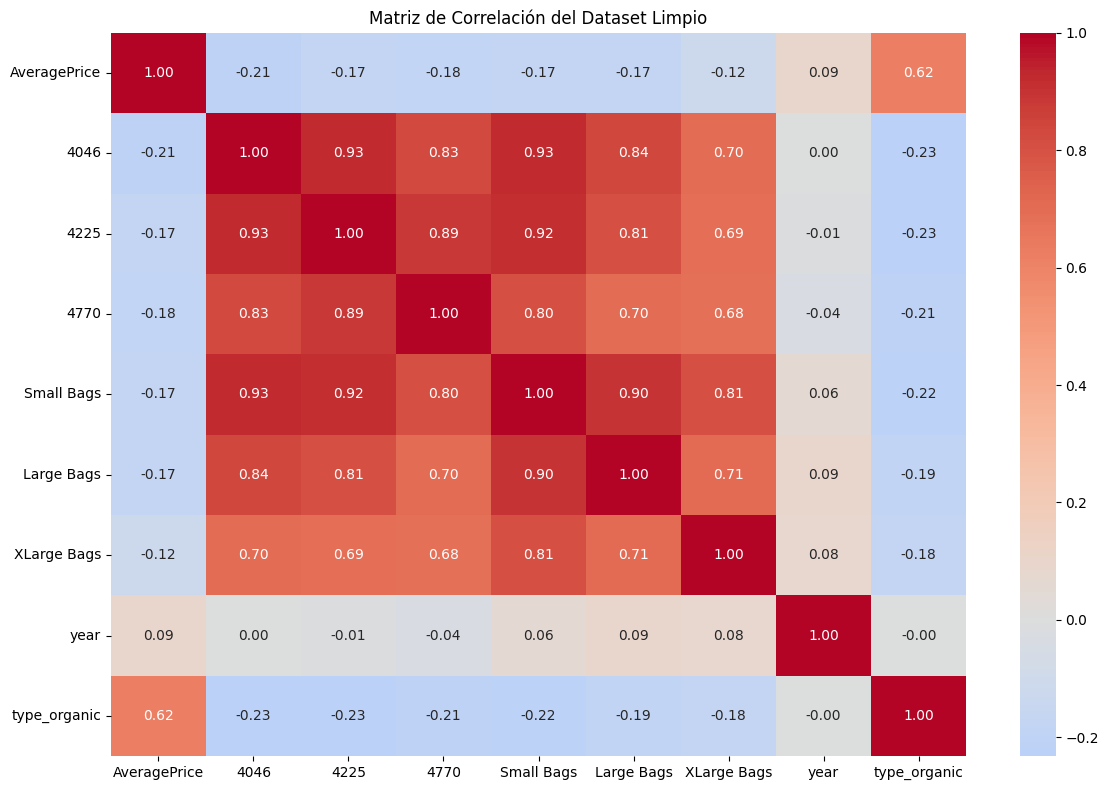

In [297]:
# Mapa de correlación del dataset limpio

df_clean = df.drop(columns=['Total Bags', 'Total Volume']) # Asegurarse de trabajar con el dataset limpio
plt.figure(figsize=(12, 8))
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación del Dataset Limpio')
plt.tight_layout()
plt.show()


In [298]:
df_clean.to_csv('avocado_clean.csv', index=False)